# HIcosmo 宇宙学模型

本教程演示 HIcosmo 支持的所有宇宙学模型。

**关键 API**：
- `list_cosmologies()` — 列出所有可用模型
- `LCDM`, `wCDM`, `CPL`, `ILCDM` — 宇宙学模型类
- `model.E_z(z)` — Hubble Parameter E(z) = H(z)/H0
- `model.w_z(z)` — Dark Energy EoS
- `model.luminosity_distance(z)` — Luminosity Distance
- `model.derived_parameters()` — 派生参数（r_d, H0_rd 等）

In [1]:
import hicosmo as hc
hc.init()

INFO:hicosmo.samplers.init:Configured 8 JAX devices × 1 threads (parallel mode)
INFO:hicosmo.samplers.init:✅ HIcosmo: 8 devices ready for parallel MCMC


True

## 1. 可用模型一览

In [2]:
from hicosmo import list_cosmologies

# 列出所有可用宇宙学模型
list_cosmologies()

[hicosmo.models.wcdm.wCDM, hicosmo.models.lcdm.LCDM, hicosmo.models.cpl.CPL]

## 2. LCDM 标准模型

$$E^2(z) = \Omega_m(1+z)^3 + \Omega_k(1+z)^2 + \Omega_r(1+z)^4 + \Omega_\Lambda$$

In [3]:
from hicosmo.models import LCDM
import numpy as np

# Planck 2018 最佳拟合参数
lcdm = LCDM(H0=67.36, Omega_m=0.3153, Omega_b=0.0493)

print(f"H0 = {lcdm.params['H0']:.2f} km/s/Mpc")
print(f"Ωm = {lcdm.params['Omega_m']:.4f}")
print(f"ΩΛ = {lcdm.params['Omega_Lambda']:.4f}")

H0 = 67.36 km/s/Mpc
Ωm = 0.3153
ΩΛ = 0.6846


In [4]:
# 核心计算方法
z = 1.0

print(f"z = {z}:")
print(f"  E(z)  = {lcdm.E_z(z):.4f}")
print(f"  w(z)  = {lcdm.w_z(z):.2f}")
print(f"  d_L   = {lcdm.luminosity_distance(z):.1f} Mpc")
print(f"  d_A   = {lcdm.angular_diameter_distance(z):.1f} Mpc")
print(f"  d_C   = {lcdm.comoving_distance(z):.1f} Mpc")
print(f"  μ     = {lcdm.distance_modulus(z):.2f} mag")

z = 1.0:
  E(z)  = 1.7912
  w(z)  = -1.00
  d_L   = 6804.7 Mpc
  d_A   = 1701.2 Mpc
  d_C   = 3402.4 Mpc
  μ     = 44.16 mag


In [5]:
# 派生参数（BAO 关键量）
derived = lcdm.derived_parameters()

print("派生参数:")
print(f"  r_d    = {derived['rd']:.2f} Mpc")
print(f"  H0*r_d = {derived['H0_rd']:.1f} km/s")

派生参数:
  r_d    = 146.93 Mpc
  H0*r_d = 9897.0 km/s


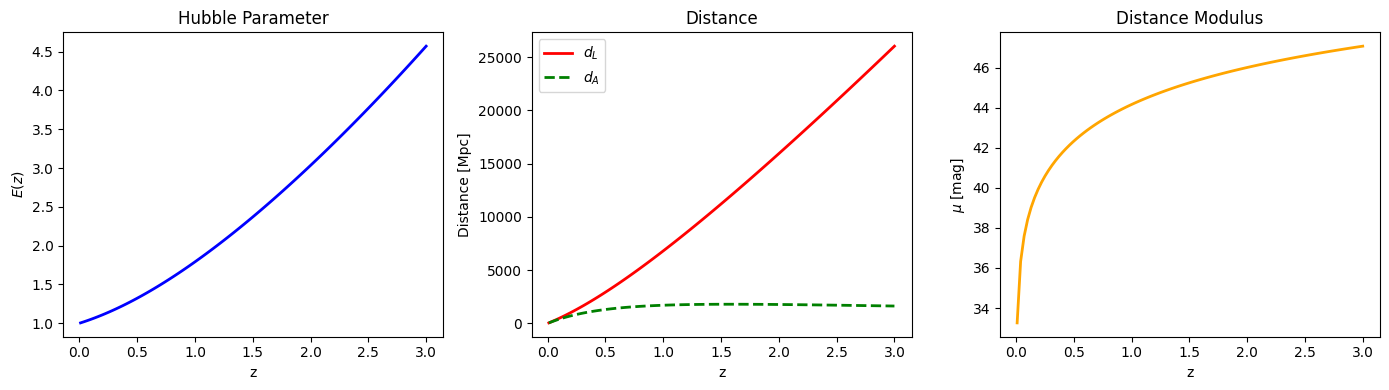

In [6]:
# 距离-红移关系
import matplotlib.pyplot as plt

z = np.linspace(0.01, 3.0, 100)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(z, [lcdm.E_z(zi) for zi in z], 'b-', lw=2)
axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$E(z)$'); axes[0].set_title('Hubble Parameter')

axes[1].plot(z, [lcdm.luminosity_distance(zi) for zi in z], 'r-', lw=2, label=r'$d_L$')
axes[1].plot(z, [lcdm.angular_diameter_distance(zi) for zi in z], 'g--', lw=2, label=r'$d_A$')
axes[1].set_xlabel('z'); axes[1].set_ylabel('Distance [Mpc]'); axes[1].legend(); axes[1].set_title('Distance')

axes[2].plot(z, [lcdm.distance_modulus(zi) for zi in z], 'orange', lw=2)
axes[2].set_xlabel('z'); axes[2].set_ylabel(r'$\mu$ [mag]'); axes[2].set_title('Distance Modulus')

plt.tight_layout()
plt.savefig('figures/02_lcdm_distances.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 3. wCDM 常数暗能量

$$E^2(z) = \Omega_m(1+z)^3 + \Omega_{DE}(1+z)^{3(1+w)}$$

In [7]:
from hicosmo.models import wCDM

# 不同 w 值的模型
models = {
    'w=-1.2 (Phantom)': wCDM(H0=70, Omega_m=0.3, w=-1.2),
    'w=-1.0 (ΛCDM)': wCDM(H0=70, Omega_m=0.3, w=-1.0),
    'w=-0.8 (Quintessence)': wCDM(H0=70, Omega_m=0.3, w=-0.8),
}

for name, m in models.items():
    print(f"{name}: w = {m.params['w']}, E(z=1) = {m.E_z(1.0):.4f}")

w=-1.2 (Phantom): w = -1.2, E(z=1) = 1.7610
w=-1.0 (ΛCDM): w = -1.0, E(z=1) = 1.7610
w=-0.8 (Quintessence): w = -0.8, E(z=1) = 1.7610


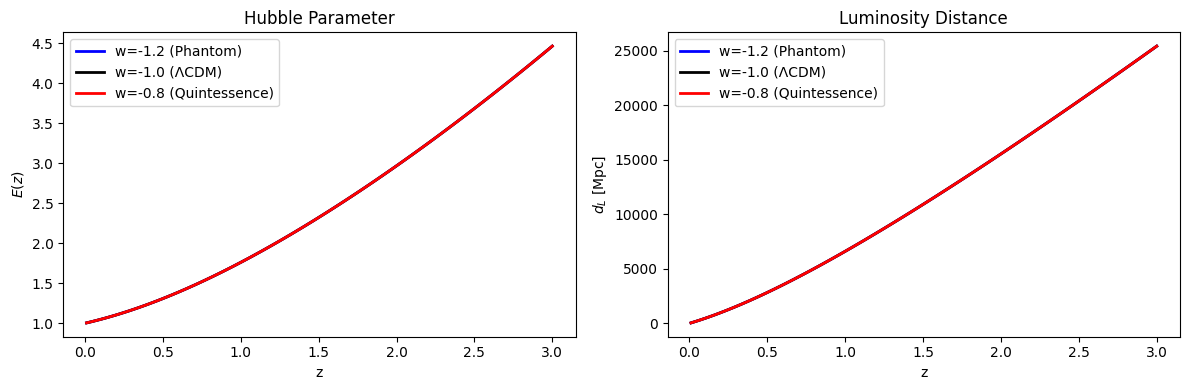

In [8]:
# 比较不同 w 值
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
z = np.linspace(0.01, 3.0, 100)
colors = ['blue', 'black', 'red']

for (name, m), c in zip(models.items(), colors):
    axes[0].plot(z, [m.E_z(zi) for zi in z], c=c, lw=2, label=name)
    axes[1].plot(z, [m.luminosity_distance(zi) for zi in z], c=c, lw=2, label=name)

axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$E(z)$'); axes[0].legend(); axes[0].set_title('Hubble Parameter')
axes[1].set_xlabel('z'); axes[1].set_ylabel(r'$d_L$ [Mpc]'); axes[1].legend(); axes[1].set_title('Luminosity Distance')

plt.tight_layout()
plt.savefig('figures/02_wcdm_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 4. CPL 演化暗能量

$$w(z) = w_0 + w_a \frac{z}{1+z}$$

In [9]:
from hicosmo.models import CPL

# 不同 (w0, wa) 组合
cpl_models = {
    'ΛCDM':      CPL(H0=70, Omega_m=0.3, w0=-1.0, wa=0.0),
    'Thawing':   CPL(H0=70, Omega_m=0.3, w0=-1.0, wa=0.5),
    'Freezing':  CPL(H0=70, Omega_m=0.3, w0=-0.9, wa=-0.3),
}

for name, m in cpl_models.items():
    print(f"{name}: w0={m.params['w0']}, wa={m.params['wa']}, w(z=0)={m.w_z(0):.2f}, w(z=1)={m.w_z(1):.2f}")

ΛCDM: w0=-1.0, wa=0.0, w(z=0)=-1.00, w(z=1)=-1.00
Thawing: w0=-1.0, wa=0.5, w(z=0)=-1.00, w(z=1)=-0.75
Freezing: w0=-0.9, wa=-0.3, w(z=0)=-0.90, w(z=1)=-1.05


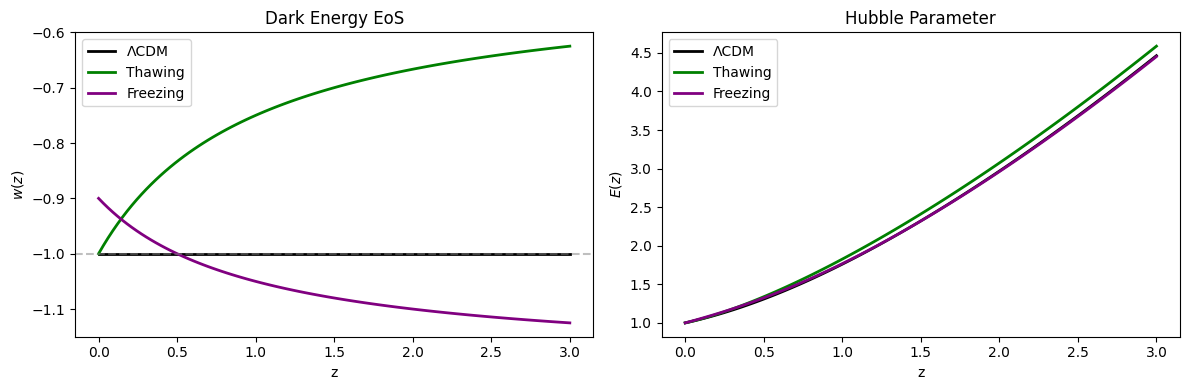

In [10]:
# w(z) 演化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
z = np.linspace(0, 3.0, 100)
colors = ['black', 'green', 'purple']

for (name, m), c in zip(cpl_models.items(), colors):
    axes[0].plot(z, [m.w_z(zi) for zi in z], c=c, lw=2, label=name)
    axes[1].plot(z, [m.E_z(zi) for zi in z], c=c, lw=2, label=name)

axes[0].axhline(-1, c='gray', ls='--', alpha=0.5)
axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$w(z)$'); axes[0].legend(); axes[0].set_title('Dark Energy EoS')
axes[1].set_xlabel('z'); axes[1].set_ylabel(r'$E(z)$'); axes[1].legend(); axes[1].set_title('Hubble Parameter')

plt.tight_layout()
plt.savefig('figures/02_cpl_evolution.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 5. ILCDM 相互作用暗能量

暗物质-暗能量相互作用: $Q = \beta H \rho_c$

In [11]:
from hicosmo.models import ILCDM

# Different Coupling Strengths
ilcdm_models = {
    'β=-0.1': ILCDM(H0=70, Omega_m=0.3, beta=-0.1),
    'β=0 (ΛCDM)': ILCDM(H0=70, Omega_m=0.3, beta=0.0),
    'β=+0.1': ILCDM(H0=70, Omega_m=0.3, beta=0.1),
}

for name, m in ilcdm_models.items():
    print(f"{name}: E(z=1) = {m.E_z(1.0):.4f}")

β=-0.1: E(z=1) = 1.8339
β=0 (ΛCDM): E(z=1) = 1.7610
β=+0.1: E(z=1) = 1.6964


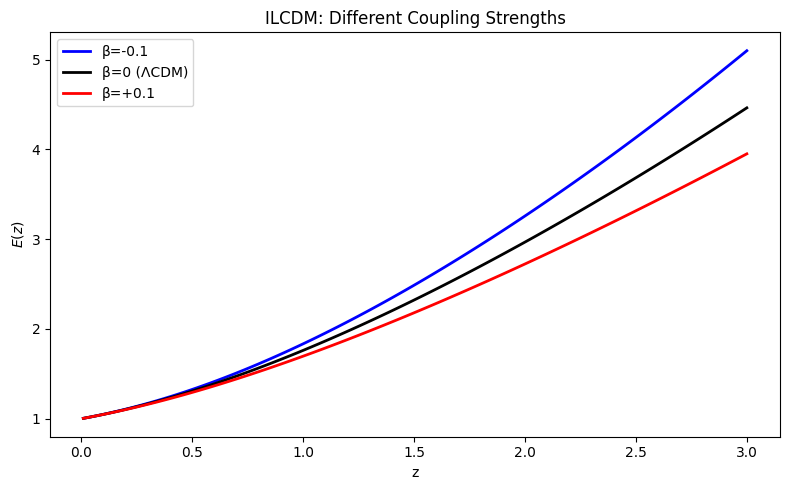

In [12]:
# 比较Different Coupling Strengths
fig, ax = plt.subplots(figsize=(8, 5))
z = np.linspace(0.01, 3.0, 100)
colors = ['blue', 'black', 'red']

for (name, m), c in zip(ilcdm_models.items(), colors):
    ax.plot(z, [m.E_z(zi) for zi in z], c=c, lw=2, label=name)

ax.set_xlabel('z'); ax.set_ylabel(r'$E(z)$'); ax.legend(); ax.set_title('ILCDM: Different Coupling Strengths')
plt.tight_layout()
plt.savefig('figures/02_ilcdm_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 6. 模型综合比较

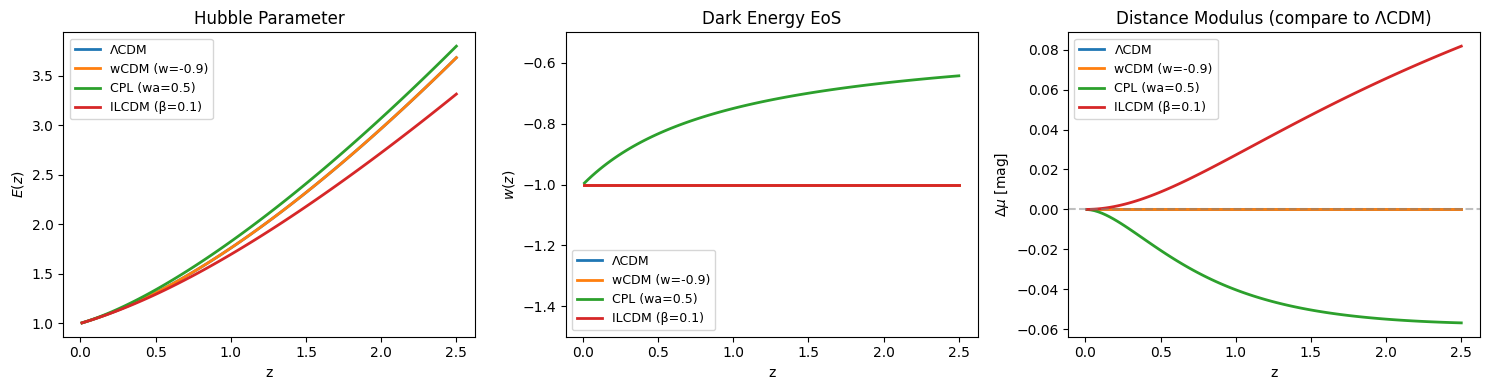

In [15]:
# 所有模型放在一起比较
all_models = {
    'ΛCDM': LCDM(H0=70, Omega_m=0.3),
    'wCDM (w=-0.9)': wCDM(H0=70, Omega_m=0.3, w=-0.9),
    'CPL (wa=0.5)': CPL(H0=70, Omega_m=0.3, w0=-1.0, wa=0.5),
    'ILCDM (β=0.1)': ILCDM(H0=70, Omega_m=0.3, beta=0.1),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
z = np.linspace(0.01, 2.5, 100)
lcdm_ref = all_models['ΛCDM']

for name, m in all_models.items():
    axes[0].plot(z, [m.E_z(zi) for zi in z], lw=2, label=name)
    axes[1].plot(z, [m.w_z(zi) for zi in z], lw=2, label=name)
    # 相对 ΛCDM 的Distance Modulus偏差
    delta_mu = [m.distance_modulus(zi) - lcdm_ref.distance_modulus(zi) for zi in z]
    axes[2].plot(z, delta_mu, lw=2, label=name)

axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$E(z)$'); axes[0].legend(fontsize=9); axes[0].set_title('Hubble Parameter')
axes[1].set_xlabel('z'); axes[1].set_ylabel(r'$w(z)$'); axes[1].legend(fontsize=9); axes[1].set_title('Dark Energy EoS'); axes[1].set_ylim(-1.5, -0.5)
axes[2].axhline(0, c='gray', ls='--', alpha=0.5)
axes[2].set_xlabel('z'); axes[2].set_ylabel(r'$\Delta\mu$ [mag]'); axes[2].legend(fontsize=9); axes[2].set_title('Distance Modulus (compare to ΛCDM)')

plt.tight_layout()
plt.savefig('figures/02_model_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()

## 7. 与 MCMC 结合

使用 `hicosmo()` 极简 API 约束模型参数：

In [14]:
from hicosmo import hicosmo

# 3 行代码约束 LCDM
inf = hicosmo('LCDM', 'sn', ['H0', 'Omega_m'])
samples = inf.run(num_samples=1000)
inf.summary()

TypeError: 'module' object is not callable

In [ ]:
# 约束 CPL 暗能量模型
inf_cpl = hicosmo('CPL', ['sn', 'bao'], ['H0', 'Omega_m', 'w0', 'wa'])
samples_cpl = inf_cpl.run(num_samples=2000)
inf_cpl.summary()

## API 速查

```python
from hicosmo import list_cosmologies
from hicosmo.models import LCDM, wCDM, CPL, ILCDM

# 查看可用模型
list_cosmologies()

# 创建模型
lcdm  = LCDM(H0=67.36, Omega_m=0.3153, Omega_b=0.0493)
wcdm  = wCDM(H0=70, Omega_m=0.3, w=-0.9)
cpl   = CPL(H0=70, Omega_m=0.3, w0=-1.0, wa=0.5)
ilcdm = ILCDM(H0=70, Omega_m=0.3, beta=0.1)

# 核心计算方法
model.E_z(z)                       # 无量纲 Hubble Parameter E(z)=H(z)/H0
model.w_z(z)                       # Dark Energy EoS
model.comoving_distance(z)         # 共动距离 [Mpc]
model.luminosity_distance(z)       # Luminosity Distance [Mpc]
model.angular_diameter_distance(z) # 角直径距离 [Mpc]
model.distance_modulus(z)          # Distance Modulus [mag]
model.sound_horizon_drag()         # 声学视界 r_d [Mpc]
model.derived_parameters()         # 派生参数字典 (rd, H0_rd, etc.)

# 极简推断 API
from hicosmo import hicosmo
inf = hicosmo('CPL', ['sn', 'bao'], ['H0', 'Omega_m', 'w0', 'wa'])
inf.run(num_samples=5000)
inf.summary()
inf.corner_plot('output.pdf')
```